# Homework - Week 4 - Evaluation of Classification Model

## Dataset Preparation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv('bank-full.csv', sep=';')
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [3]:
# select the relevant columns to use
relevant_cols = ['age', 'job', 'marital', 'education', 'balance', 'housing', 'contact', 'day', 
                 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y'] 

df = df[relevant_cols].copy()

In [4]:
# Encode the target 'y' to 0/1

df['y'] = (df['y'] == 'yes').astype('int')

In [5]:
# Split the data into training, validation, and test

df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state =1)

df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

y_train = df_train.y.values
y_val = df_val.y.values
y_test = df_test.y.values

del df_train['y']
del df_val['y']
del df_test['y']

In [6]:
num_cols = list(df.dtypes[(df.dtypes == 'int64')].index)
num_cols.remove('y')
cat_cols = list(df.dtypes[(df.dtypes == 'object')].index)

In [7]:
num_cols

['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

## Question 1: ROC AUC feature importance

ROC AUC could be used to evaluate feature importance of numercial variables.
- For each numerical variable, use it as score and compute the AUC with the y variable as ground truth
- Use the training dataset for evaluation

In [8]:
from sklearn.metrics import auc, roc_auc_score, roc_curve

In [9]:
for c in num_cols:
    auc = roc_auc_score(y_train, df_train[c])
    if auc < 0.5:
        auc = roc_auc_score(y_train, -df_train[c])
    print (c, '%.3f' % (auc))

age 0.512
balance 0.589
day 0.526
duration 0.815
campaign 0.571
pdays 0.590
previous 0.599


*duration* has the highest auc score.

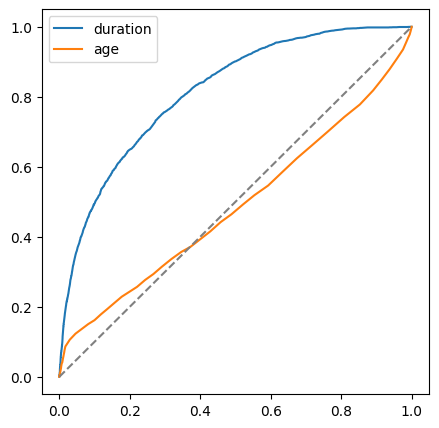

In [10]:
plt.figure(figsize=(5, 5))

fpr, tpr, _ = roc_curve(y_train, df_train.duration)
plt.plot(fpr, tpr, label='duration')

fpr, tpr, _ = roc_curve(y_train, df_train.age)
plt.plot(fpr, tpr, label='age')

plt.plot([0, 1], [0, 1], color='grey', linestyle='--')

plt.legend()
plt.show()

## Question 2: Training the model

In [11]:
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression

In [12]:
dicts_train = df_train[cat_cols + num_cols].to_dict(orient='records')
dicts_val = df_val[cat_cols + num_cols].to_dict(orient='records')

dv = DictVectorizer()
X_train = dv.fit_transform(dicts_train)
X_val = dv.transform(dicts_val)

model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict_proba(X_val)[:, 1]

roc_auc_score(y_val, y_pred)

0.9002510973902931

## Question 3: Precision and Recall

- Evaluate the model on all thresholds from 0.0 to 1..0 with step 0.01
- For each threshold, compute precision and recall
- Plot the precision and recall curves

In [13]:
def confusion_matrix_dataframe(y_val, y_pred):
    scores = []

    thresholds = np.linspace(0, 1, 101)

    for t in thresholds:
        actual_positive = (y_val == 1)
        actual_negative = (y_val == 0)

        predict_positive = (y_pred >= t)
        predict_negative = (y_pred < t)

        tp = (predict_positive & actual_positive).sum()
        tn = (predict_negative & actual_negative).sum()

        fp = (predict_positive & actual_negative).sum()
        fn = (predict_negative & actual_positive).sum()

        scores.append((t, tp, fp, fn, tn))

    columns = ['threshold', 'tp', 'fp', 'fn', 'tn']
    df_scores = pd.DataFrame(scores, columns=columns)
    
    return df_scores

In [14]:
df_scores = confusion_matrix_dataframe(y_val, y_pred)

In [15]:
df_scores[::10]

,threshold,tp,fp,fn,tn
0,0.0,1098,7944,0,0
10,0.1,927,1494,171,6450
20,0.2,709,697,389,7247
30,0.3,568,413,530,7531
40,0.4,463,275,635,7669
50,0.5,371,190,727,7754
60,0.6,291,137,807,7807
70,0.7,225,102,873,7842
80,0.8,149,66,949,7878
90,0.9,76,28,1022,7916


In [16]:
df_scores['precision'] = df_scores.tp / (df_scores.tp + df_scores.fp)
df_scores['recall'] = df_scores.tp / (df_scores.tp + df_scores.fn)

Precision and recall cross between 0.2 and 0.3 threshold. Therefore, the answer is 0.265

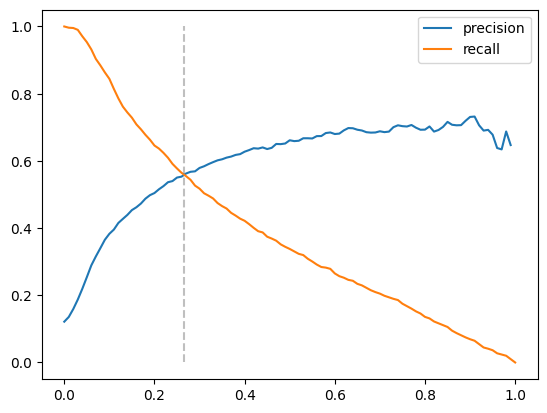

In [17]:
plt.plot(df_scores.threshold, df_scores.precision, label='precision')
plt.plot(df_scores.threshold, df_scores.recall, label='recall')

plt.vlines(0.265, 0, 1, color='grey', linestyle='--', alpha=0.5)

plt.legend()
plt.show()

### Question 4: F1 Score

Precision and recall are conflicting measures, as one goes up, the other goes down. That's why they are often combined into the F1 score - a metrics that takes into account both ratio. F1 = 2 * P * R / (P + R).

Compute F1 for all threshold from 0.0 to 1.0.

In [19]:
df_scores[::10]

,threshold,tp,fp,fn,tn,precision,recall
0,0.0,1098,7944,0,0,0.121433,1.000000
10,0.1,927,1494,171,6450,0.382900,0.844262
20,0.2,709,697,389,7247,0.504267,0.645719
30,0.3,568,413,530,7531,0.579001,0.517304
40,0.4,463,275,635,7669,0.627371,0.421676
50,0.5,371,190,727,7754,0.661319,0.337887
60,0.6,291,137,807,7807,0.679907,0.265027
70,0.7,225,102,873,7842,0.688073,0.204918
80,0.8,149,66,949,7878,0.693023,0.135701
90,0.9,76,28,1022,7916,0.730769,0.069217


In [20]:
df_scores['f1_score'] = 2 * df_scores.precision * df_scores.recall / (df_scores.precision + df_scores.recall)

In [24]:
df_scores[df_scores['f1_score'] == df_scores['f1_score'].max()]

,threshold,tp,fp,fn,tn,precision,recall,f1_score
23,0.23,669,578,429,7366,0.536488,0.60929,0.570576


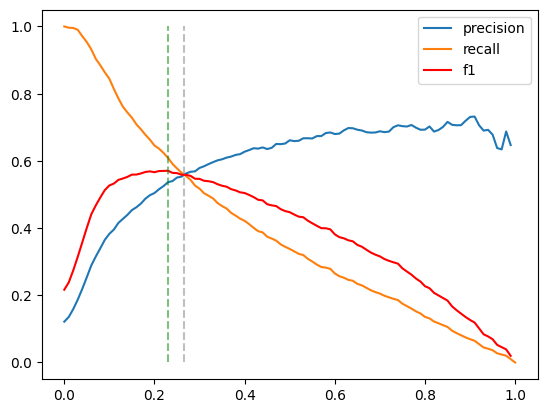

In [28]:
plt.plot(df_scores.threshold, df_scores.precision, label='precision')
plt.plot(df_scores.threshold, df_scores.recall, label='recall')
plt.plot(df_scores.threshold, df_scores.f1_score, label='f1', color='red')

plt.vlines(0.265, 0, 1, color='grey', linestyle='--', alpha=0.5)
plt.vlines(0.23, 0, 1, color='green', linestyle = '--', alpha=0.5)

plt.legend()
plt.show()

### Question 5: 5-Fold CV

In [29]:
from sklearn.model_selection import KFold
from tqdm.auto import tqdm

In [30]:
# function to train model

def train(df_train, y_train, C=1.0):
    dicts = df_train.to_dict(orient='records')

    dv = DictVectorizer(sparse=False)
    X_train = dv.fit_transform(dicts)

    model = LogisticRegression(solver='liblinear', C=C, max_iter=1000)
    model.fit(X_train, y_train)

    return dv, model

In [31]:
# function to predict the validation set

def predict(df, dv, model):
    dicts = df.to_dict(orient='records')

    X = dv.transform(dicts)
    y_pred = model.predict_proba(X)[:, 1]

    return y_pred

In [37]:
scores = []
kfold = KFold(n_splits = 5, shuffle=True, random_state=1)

for train_idx, val_idx in tqdm(kfold.split(df_full_train)):
    df_train = df_full_train.iloc[train_idx].copy()
    df_val = df_full_train.iloc[val_idx].copy()

    y_train = df_train.y.values
    y_val = df_val.y.values

    del df_train['y']
    del df_val['y']

    dv, model = train(df_train, y_train, C=1.0)
    y_pred = predict(df_val, dv, model)

    auc = roc_auc_score(y_val, y_pred)
    scores.append(auc)

0it [00:00, ?it/s]

In [38]:
np.std(scores)

np.float64(0.005611296539126669)

In [39]:
scores

[0.8993556310932126,
 0.8993206548548723,
 0.9112583997605899,
 0.9081048228522398,
 0.9120491718502978]